In [6]:
import os
import pickle
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pl.scan_parquet('train.parquet').collect().to_pandas()
valid = pl.scan_parquet("valid.parquet").collect().to_pandas()
feature_names = [f"feature_{i:02d}" for i in range(79)] + [f"responder_{idx}_lag_1" for idx in range(9)]
label_name = 'responder_6'
X_train = df[ feature_names ]
y_train = df[ label_name ]
w_train = df[ "weight" ]
X_valid = valid[ feature_names ]
y_valid = valid[ label_name ]
w_valid = valid[ "weight" ]

X_train.shape, y_train.shape, w_train.shape, X_valid.shape, y_valid.shape, w_valid.shape

((21022056, 88),
 (21022056,),
 (21022056,),
 (1082224, 88),
 (1082224,),
 (1082224,))

In [21]:
df.columns

Index(['id', 'date_id', 'time_id', 'symbol_id', 'weight', 'feature_00',
       'feature_01', 'feature_02', 'feature_03', 'feature_04',
       ...
       'label', 'responder_0_lag_1', 'responder_1_lag_1', 'responder_2_lag_1',
       'responder_3_lag_1', 'responder_4_lag_1', 'responder_5_lag_1',
       'responder_6_lag_1', 'responder_7_lag_1', 'responder_8_lag_1'],
      dtype='object', length=104)

In [29]:
# df_eda = df.head(1000000)
df_eda = df
df_eda = df_eda[ (df_eda.symbol_id == 1)]
df_eda.shape, df_eda.columns

((532400, 104),
 Index(['id', 'date_id', 'time_id', 'symbol_id', 'weight', 'feature_00',
        'feature_01', 'feature_02', 'feature_03', 'feature_04',
        ...
        'label', 'responder_0_lag_1', 'responder_1_lag_1', 'responder_2_lag_1',
        'responder_3_lag_1', 'responder_4_lag_1', 'responder_5_lag_1',
        'responder_6_lag_1', 'responder_7_lag_1', 'responder_8_lag_1'],
       dtype='object', length=104))

(1000000,) (1000000,)


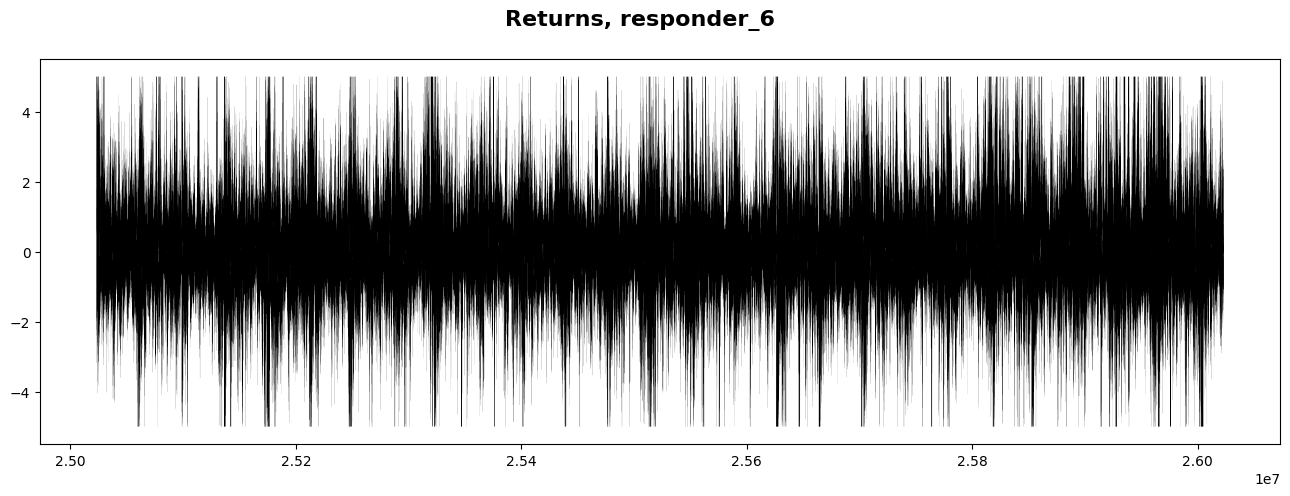

In [ ]:
xx = df_eda['id']
yy = df_eda['responder_6']
# zz = df_eda['responder_0_lag_1']
print(xx.shape, yy.shape)
plt.figure(figsize=(16, 5))
plt.plot(xx,yy, color = 'black', linewidth =0.05)
plt.suptitle('Returns, responder_6', weight='bold', fontsize=16)
plt.show()

/tmp/ipykernel_474918/2158651158.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


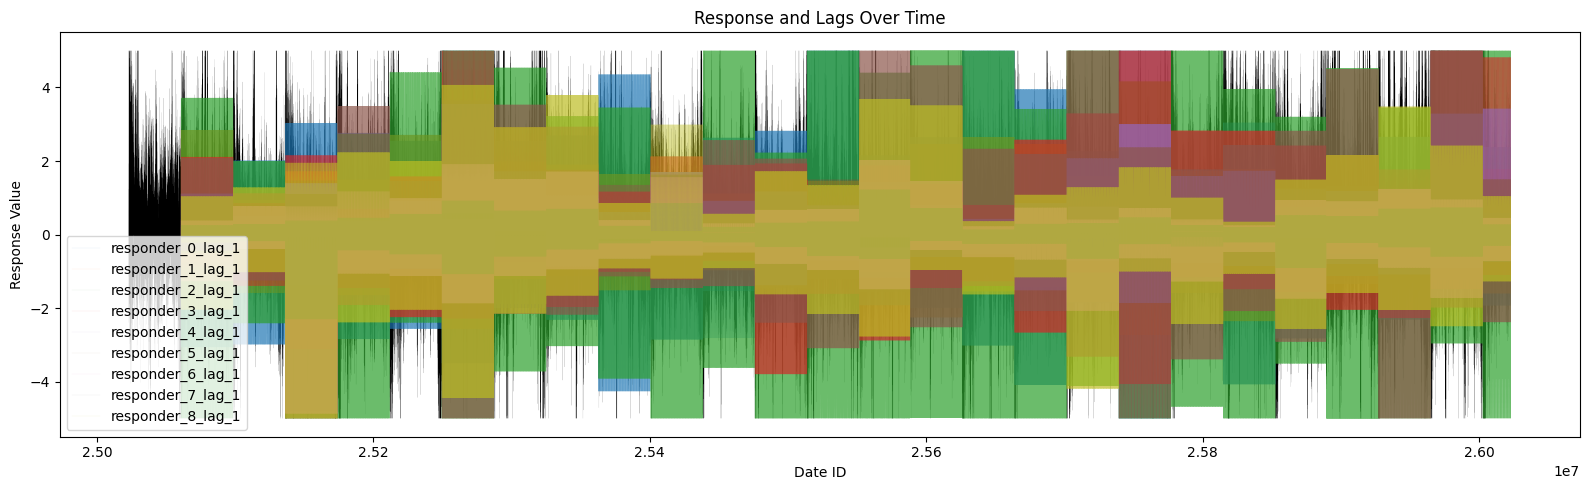

In [52]:
# plot each lag onto same plot
yy = df_eda['responder_6']
plt.figure(figsize=(16, 5))
plt.plot(xx,yy, color = 'black', linewidth =0.05)
for i in range(9):
    yy = df_eda[f'responder_{i}_lag_1']
    plt.plot(xx,yy, linewidth =0.05, alpha=0.7, label=f'responder_{i}_lag_1')
plt.xlabel('Date ID')
plt.ylabel('Response Value')
plt.title('Response and Lags Over Time')
plt.legend()
plt.tight_layout()

# Show the combined plot
plt.show()

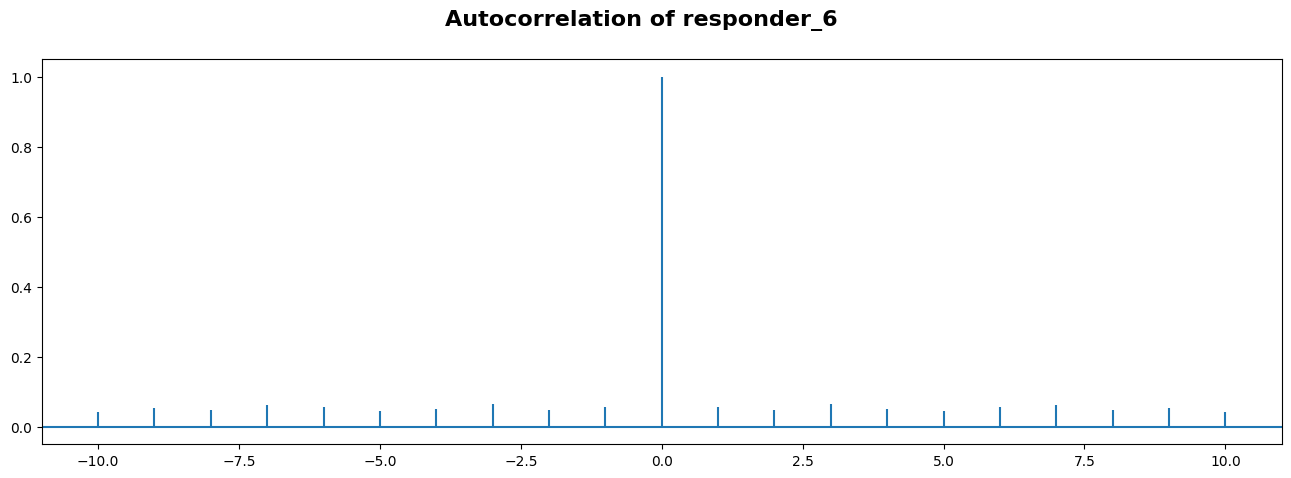

In [53]:
xx = df_eda['id']
yy = df_eda['responder_6']
# autocorrelation of yy
plt.figure(figsize=(16, 5))
plt.acorr(yy, maxlags=10)
plt.suptitle('Autocorrelation of responder_6', weight='bold', fontsize=16)
plt.show()

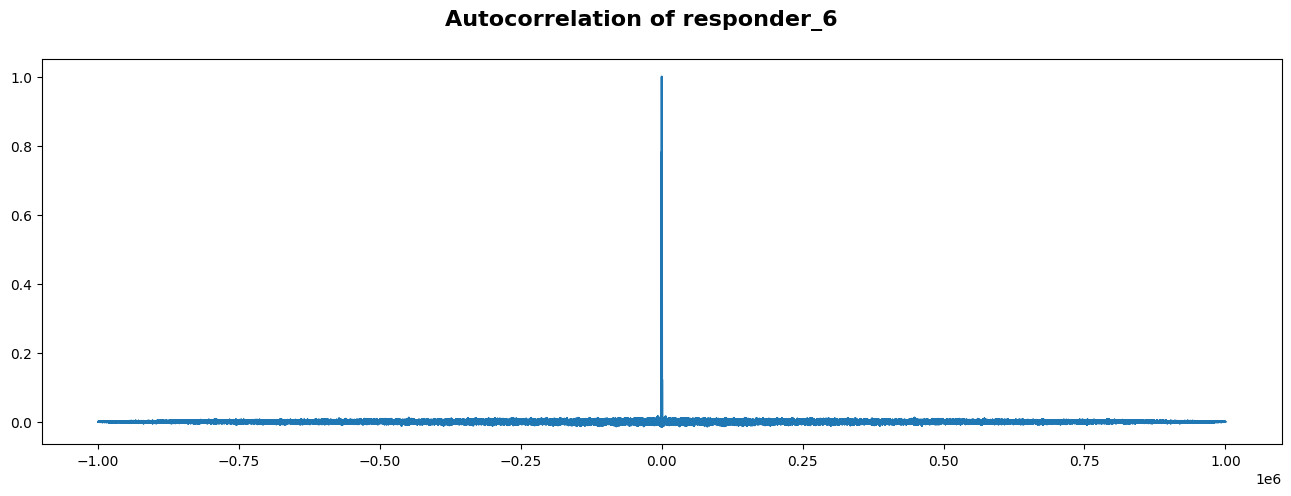

In [54]:
autocorr = np.correlate(yy, yy, mode='full')
lags = np.arange(-len(yy)+1, len(yy))
autocorr = autocorr / autocorr.max()
plt.figure(figsize=(16, 5))
plt.plot(lags, autocorr)
plt.suptitle('Autocorrelation of responder_6', weight='bold', fontsize=16)
plt.show()

In [37]:
df.date_id.values

array([1101, 1101, 1101, ..., 1669, 1669, 1669], dtype=int16)

<Axes: xlabel='responder_6', ylabel='Count'>

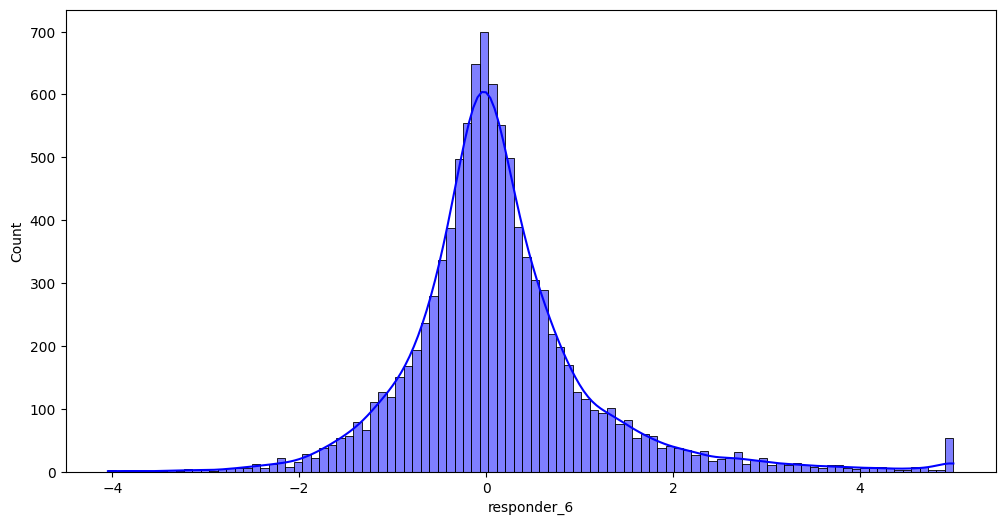

In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(y_train[:10000], bins=100, color='blue', kde=True, label='train')

In [60]:
y_train = y_train.to_numpy(dtype=float)  # Convert to numpy array with float dtype
y_train.shape

(21022056,)

In [62]:
from scipy.fft import fft
yf = fft(y_train)

/home/jx1421/JS-Kaggle-JX/js-venv/lib64/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


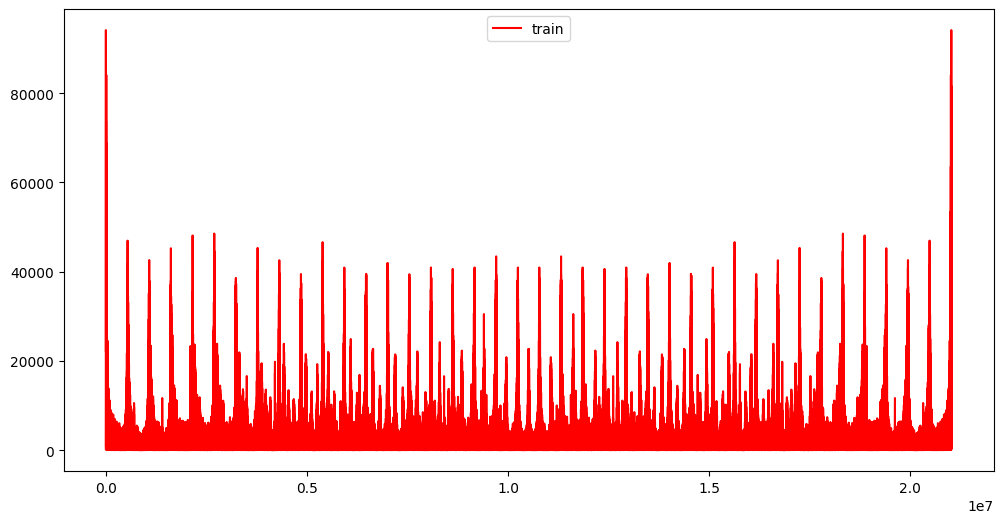

In [71]:
yf = np.abs(yf)
plt.figure(figsize=(12, 6))
plt.plot(yf, color='red', label='train')
plt.legend()
plt.show()

In [73]:
largest_indices = np.argsort(yf)[-2:] 
largest_vals = yf[largest_indices]
largest_indices, largest_vals

(array([     373, 21021683]), array([94133.68678741, 94133.68678741]))

100000.0

# FFT for responder_6 of symbol_1

In [ ]:
1e7

In [69]:
yy = df_eda['responder_6']
yy = yy.to_numpy(dtype=float)
print(yy.shape)
yy_ft = fft(yy)

(1000000,)


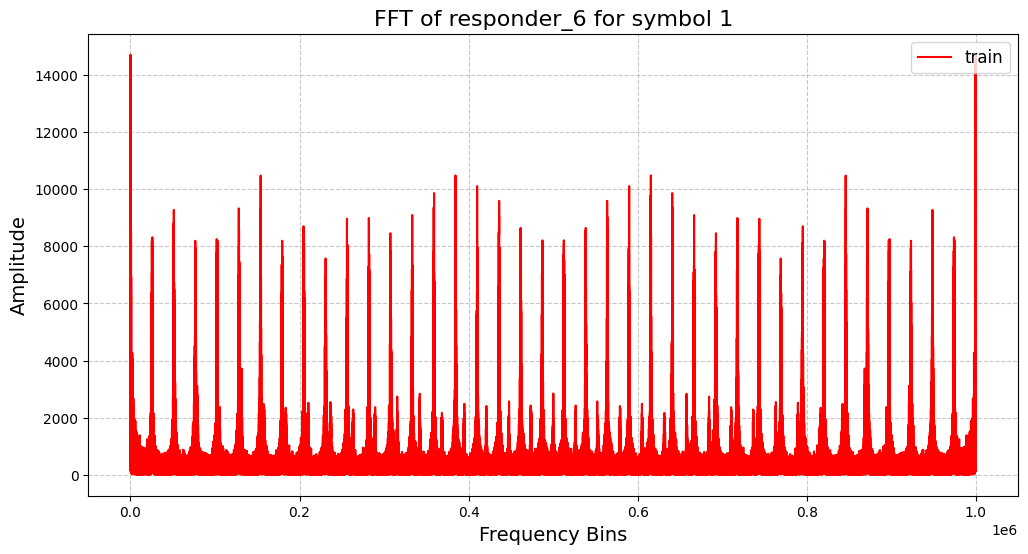

In [68]:
# for symbol1 fft
yy_ft = np.abs(yy_ft)
plt.figure(figsize=(12, 6))
plt.plot(yy_ft, color='red', label='train')
plt.xlabel('Frequency Bins', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('FFT of responder_6 for symbol 1', fontsize=16)
plt.show()